<a href="https://colab.research.google.com/github/samif0/orion/blob/main/experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Orion — Experiments Notebook

Runs and compares training + eval across attention backends: **dense**, **window**, and **sparse**.

Uses `orion.run` — the unified train+eval runner from the project.

| Backend | Config |
|---|---|
| Dense  | `configs/tinyshakespeare_dense.yaml`  |
| Window | `configs/tinyshakespeare_window.yaml` |
| Sparse | `configs/tinyshakespeare_sparse.yaml` |

## 1. Setup

In [1]:
import os, subprocess, sys

# Clone and install (Colab only — skip if running locally)
if not os.path.exists('orion'):
    subprocess.run(['git', 'clone', 'https://github.com/samif0/orion.git'], check=True)
    os.chdir('orion')
elif os.path.basename(os.getcwd()) != 'orion':
    os.chdir('orion')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                '-r', 'requirements.txt', '-r', 'requirements-dev.txt',
                'pandas', 'matplotlib'], check=True)
print('Setup complete. cwd:', os.getcwd())

Setup complete. cwd: /Users/samif0/Projects/orion


In [2]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch {torch.__version__} | device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"}')

torch 2.10.0 | device: cpu


## 2. Config

In [8]:
# ── Tune these ────────────────────────────────────────────────────
STEPS     = 1000 
RUN_DENSE  = True
RUN_WINDOW = True
RUN_SPARSE = True
# ──────────────────────────────────────────────────────────────────

EXPERIMENTS = {
    'dense':  {'config': 'configs/tinyshakespeare_dense.yaml',  'run': RUN_DENSE},
    'window': {'config': 'configs/tinyshakespeare_window.yaml', 'run': RUN_WINDOW},
    'sparse': {'config': 'configs/tinyshakespeare_sparse.yaml', 'run': RUN_SPARSE},
}

## 3. Train + Eval (via `orion.run`)

In [9]:
import time, json
from pathlib import Path

run_results = {}

for name, exp in EXPERIMENTS.items():
    if not exp['run']:
        print(f'[{name}] skipped')
        continue

    print(f'\n=== {name.upper()} | config: {exp["config"]} | steps: {STEPS} ===')
    t0 = time.time()

    result = subprocess.run(
        [
            sys.executable, '-m', 'orion.run',
            '--config', exp['config'],
            '--mode', 'both',
            '--device', device,
            '--run-id', name,
            '--steps', str(STEPS),
        ],
        capture_output=False,
    )

    elapsed = time.time() - t0
    status = '✅' if result.returncode == 0 else '❌'
    print(f'{status} {name} | {elapsed:.1f}s | rc={result.returncode}')

    # Read eval.json written by orion.run
    from orion.run_paths import resolve_run_paths
    from orion.config import load_config
    cfg = load_config(exp['config'])
    paths = resolve_run_paths(cfg.raw, run_id_override=name)
    eval_path = paths.out_dir / 'eval.json'
    eval_metrics = json.loads(eval_path.read_text()) if eval_path.exists() else {}

    run_results[name] = {
        'returncode': result.returncode,
        'elapsed_s': round(elapsed, 1),
        'out_dir': str(paths.out_dir),
        **eval_metrics,
    }

print('\n--- Summary ---')
for name, r in run_results.items():
    print(f"{name:8} | loss: {r.get('loss', 'N/A'):.4f} | ppl: {r.get('ppl', 'N/A'):.2f} | {r['elapsed_s']}s")


=== DENSE | config: configs/tinyshakespeare_dense.yaml | steps: 1000 ===
{'step': 50, 'loss': 2.636259078979492, 'ppl': 13.9608793258667}
{'step': 100, 'loss': 2.5043935775756836, 'ppl': 12.236136436462402}
{'step': 150, 'loss': 2.542959451675415, 'ppl': 12.717251777648926}
{'step': 200, 'loss': 2.5003502368927, 'ppl': 12.186761856079102}
{'step': 250, 'loss': 2.461291790008545, 'ppl': 11.719941139221191}
{'step': 300, 'loss': 2.423642635345459, 'ppl': 11.286898612976074}
{'step': 350, 'loss': 2.391033172607422, 'ppl': 10.924775123596191}
{'step': 400, 'loss': 2.4161219596862793, 'ppl': 11.20233154296875}
{'step': 450, 'loss': 2.3693814277648926, 'ppl': 10.690776824951172}
{'step': 500, 'loss': 2.3607590198516846, 'ppl': 10.598993301391602}
{'step': 550, 'loss': 2.306896686553955, 'ppl': 10.043209075927734}
{'step': 600, 'loss': 2.262744665145874, 'ppl': 9.609427452087402}
{'step': 650, 'loss': 2.152918577194214, 'ppl': 8.60995101928711}
{'step': 700, 'loss': 2.1629536151885986, 'ppl'

## 4. Compare Metrics

[dense] 24 steps logged
[window] 24 steps logged
[sparse] 24 steps logged


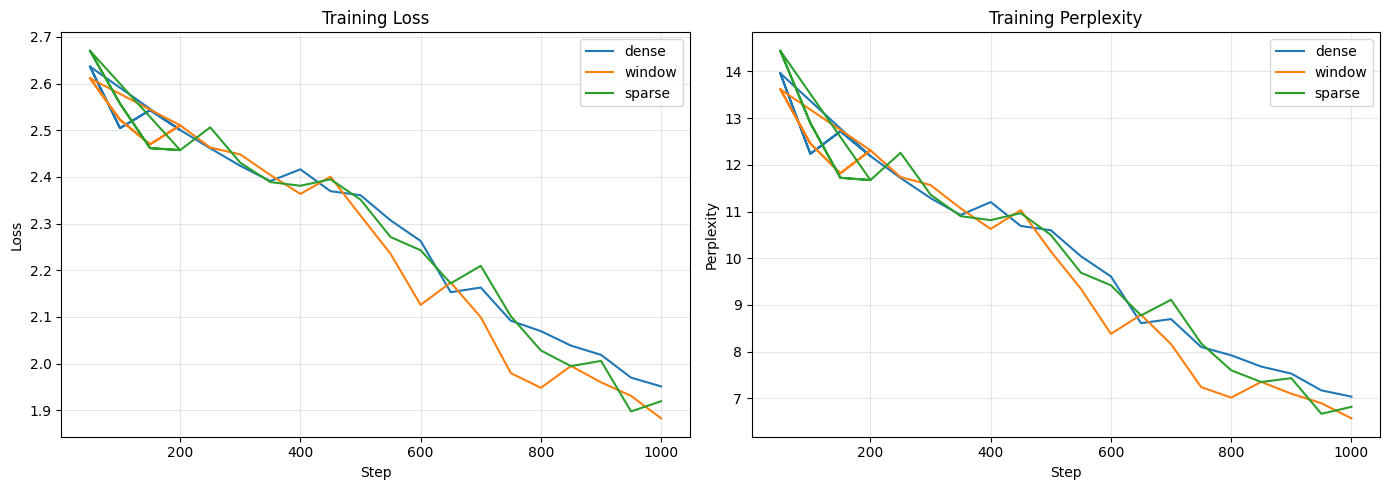

Saved: runs/comparison.png


In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt

metrics = {}

for name, r in run_results.items():
    jsonl_path = Path(r['out_dir']) / 'metrics.jsonl'
    if not jsonl_path.exists():
        print(f'[{name}] no metrics.jsonl at {jsonl_path}')
        continue
    rows = [json.loads(l) for l in jsonl_path.read_text().splitlines() if l.strip()]
    metrics[name] = pd.DataFrame(rows)
    print(f'[{name}] {len(rows)} steps logged')

# Loss curve
if metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, df in metrics.items():
        if 'loss' in df.columns and 'step' in df.columns:
            axes[0].plot(df['step'], df['loss'], label=name)
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for name, df in metrics.items():
        if 'ppl' in df.columns and 'step' in df.columns:
            axes[1].plot(df['step'], df['ppl'], label=name)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Perplexity')
    axes[1].set_title('Training Perplexity')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('runs/comparison.png', dpi=150)
    plt.show()
    print('Saved: runs/comparison.png')

In [12]:
# Summary table
rows = []
for name, r in run_results.items():
    df = metrics.get(name)
    final_loss = float(df['loss'].iloc[-1]) if df is not None and 'loss' in df.columns else None
    rows.append({
        'backend':      name,
        'final_loss':   round(final_loss, 4) if final_loss else 'N/A',
        'eval_loss':    round(r.get('loss', float('nan')), 4),
        'eval_ppl':     round(r.get('ppl',  float('nan')), 2),
        'train_time_s': r['elapsed_s'],
    })

summary = pd.DataFrame(rows).set_index('backend')
print(summary.to_string())

         final_loss  eval_loss  eval_ppl  train_time_s
backend                                               
dense        1.9512     7.5149   1835.17          78.8
window       1.8828     7.4836   1778.67         138.4
sparse       1.9195     7.5103   1826.80          88.6


## 5. Custom Run

In [7]:
CUSTOM_CONFIG = 'configs/tinyshakespeare_window.yaml'
CUSTOM_STEPS  = 500
CUSTOM_RUN_ID = 'custom-window'

subprocess.run([
    sys.executable, '-m', 'orion.run',
    '--config',     CUSTOM_CONFIG,
    '--mode',       'both',
    '--device',     device,
    '--run-id',     CUSTOM_RUN_ID,
    '--steps', str(CUSTOM_STEPS),
])

{'step': 50, 'loss': 2.611468553543091, 'ppl': 13.619036674499512}
{'step': 100, 'loss': 2.5222256183624268, 'ppl': 12.456289291381836}
{'step': 150, 'loss': 2.469686508178711, 'ppl': 11.818740844726562}
{'step': 200, 'loss': 2.5104598999023438, 'ppl': 12.310590744018555}
{'step': 250, 'loss': 2.462812900543213, 'ppl': 11.73778247833252}
{'step': 300, 'loss': 2.4481515884399414, 'ppl': 11.566946029663086}
{'step': 350, 'loss': 2.404059886932373, 'ppl': 11.06801986694336}
{'step': 400, 'loss': 2.3633952140808105, 'ppl': 10.626971244812012}
{'step': 450, 'loss': 2.4005038738250732, 'ppl': 11.028732299804688}
{'step': 500, 'loss': 2.3170359134674072, 'ppl': 10.145557403564453}


CompletedProcess(args=['/Users/samif0/Projects/orion/.venv/bin/python', '-m', 'orion.run', '--config', 'configs/tinyshakespeare_window.yaml', '--mode', 'both', '--device', 'cpu', '--run-id', 'custom-window', '--steps', '500'], returncode=0)